<a href="https://colab.research.google.com/github/maabmusa7/BinX_Tech_Internship_Project_GROUP5/blob/ai%2Fwhisperx-pronunciation-scoring/ai-ml/stt-whisperx/whisperx_pronunciation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook explores the **speechocean762** dataset, which will serve as the primary source for training and evaluating our pronunciation-scoring pipeline (built on top of WhisperX). The goal of this EDA is to understand the structure and quality of the data
before using it to calibrate a confidence threshold for flagging mispronounced words.

## Feature Dictionary

| Feature | Description |
|---|---|
| `speaker` | Unique ID representing the speaker (same speaker may appear in multiple recordings) |
| `gender` | Speaker's gender (m/f) |
| `age` | Speaker's age at the time of recording |
| `text` | The target sentence the speaker was supposed to say (reference transcript) |
| `accuracy` | Human-rated score (0–10) for overall pronunciation accuracy of the **whole sentence** |
| `completeness` | Human-rated score (0–10) for whether the speaker said **all** the words (no skipping) |
| `fluency` | Human-rated score (0–10) for speech smoothness — pauses, hesitation, natural rhythm |
| `prosodic` | Human-rated score (0–10) for intonation and stress patterns naturalness |
| `total` | Overall score summarizing the four scores above |
| `words` | Nested list with per-word detail: word-level `accuracy`, `stress`, and `phones` (the individual sounds making up the word) with `phones-accuracy` for each |

In [ ]:
# importing the speechocean762 DataSet
from datasets import load_dataset

train_set = load_dataset("mispeech/speechocean762", split="train")
test_set = load_dataset("mispeech/speechocean762", split="test")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import pandas as pd

# change the sets to pandas (without the audio coloumn)
train_df = train_set.remove_columns(["audio"]).to_pandas()
test_df = test_set.remove_columns(["audio"]).to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (2500, 10)
Test shape: (2500, 10)


,accuracy,completeness,fluency,prosodic,text,total,words,speaker,gender,age
0,8,10.0,9,9,WE CALL IT BEAR,8,"[{'accuracy': 10, 'phones': ['W', 'IY0'], 'pho...",0001,m,6
1,8,10.0,9,9,ZERO THREE FIVE ONE,8,"[{'accuracy': 8, 'phones': ['Z', 'IH1', 'R', '...",0001,m,6
2,9,10.0,10,10,THREE TWO TWO SEVEN,9,"[{'accuracy': 10, 'phones': ['TH', 'R', 'IY0']...",0001,m,6
3,10,10.0,9,9,ELEPHANTS TAI GOOSE,9,"[{'accuracy': 10, 'phones': ['EH1', 'L', 'IH0'...",0001,m,6
4,9,10.0,9,10,TOM GIVES UP BOXING,9,"[{'accuracy': 10, 'phones': ['T', 'AA0', 'M'],...",0001,m,6


In [ ]:
print("Train")
print("train info", train_df.info())

print("Test")
print("test info",test_df.info())

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accuracy      2500 non-null   int64  
 1   completeness  2500 non-null   float64
 2   fluency       2500 non-null   int64  
 3   prosodic      2500 non-null   int64  
 4   text          2500 non-null   object 
 5   total         2500 non-null   int64  
 6   words         2500 non-null   object 
 7   speaker       2500 non-null   object 
 8   gender        2500 non-null   object 
 9   age           2500 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 195.4+ KB
train info None
Test
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accuracy      2500 non-null   int64  
 1   completeness  2500 non-null   float64
 2   fl

**No null values found** in either split — all 2500 rows in train and test have complete data across all columns. This means we don't need any missing-value imputation before analysis.

In [ ]:
print("TRAIN")
print(train_df[["accuracy","completeness","fluency","prosodic","total"]].describe())

print("\nTEST")
print(test_df[["accuracy","completeness","fluency","prosodic","total"]].describe())

TRAIN
          accuracy  completeness      fluency     prosodic        total
count  2500.000000   2500.000000  2500.000000  2500.000000  2500.000000
mean      7.618400      9.993760     7.728400     7.422400     7.181200
std       1.694559      0.108286     1.555249     1.502825     1.668736
min       3.000000      6.700000     1.000000     1.000000     2.000000
25%       7.000000     10.000000     7.000000     7.000000     7.000000
50%       8.000000     10.000000     8.000000     8.000000     8.000000
75%       9.000000     10.000000     9.000000     8.000000     8.000000
max      10.000000     10.000000    10.000000    10.000000    10.000000

TEST
          accuracy  completeness      fluency     prosodic        total
count  2500.000000   2500.000000  2500.000000  2500.000000  2500.000000
mean      7.695600      9.966080     7.839600     7.501600     7.263200
std       1.538534      0.511846     1.425302     1.433464     1.549608
min       1.000000      0.000000     0.000000     0.

**completeness** has a very high mean (9.99) and very low std (~0.1-0.5) in
both splits meaning almost all speakers say the full sentence without
skipping words. This column has little variance, so it may not be very useful for distinguishing pronunciation quality later.

**accuracy, fluency, and prosodic** show more spread (std ~1.4-1.7) — these are the columns most likely to carry meaningful signal for our threshold calibration.

**The total score** min drops as low as 0 in test but only 2 in train — test contains harder/more extreme cases than train.

In [ ]:
print("\nTrain - unique speakers:", train_df["speaker"].nunique())
print("Test - unique speakers:", test_df["speaker"].nunique())


Train - unique speakers: 125
Test - unique speakers: 125


In [ ]:
# to make sure that every speaker on the test set is new and there is no data leakage
train_speakers = set(train_df["speaker"].unique())
test_speakers = set(test_df["speaker"].unique())
overlap = train_speakers.intersection(test_speakers)

print(f"Speakers overlapping between train/test: {len(overlap)}")

Speakers overlapping between train/test: 0


125 unique speakers per split, zero overlap between train and test. This confirms the official split design and rules out speaker-level data leakage — any evaluation results on the test set will be trustworthy.

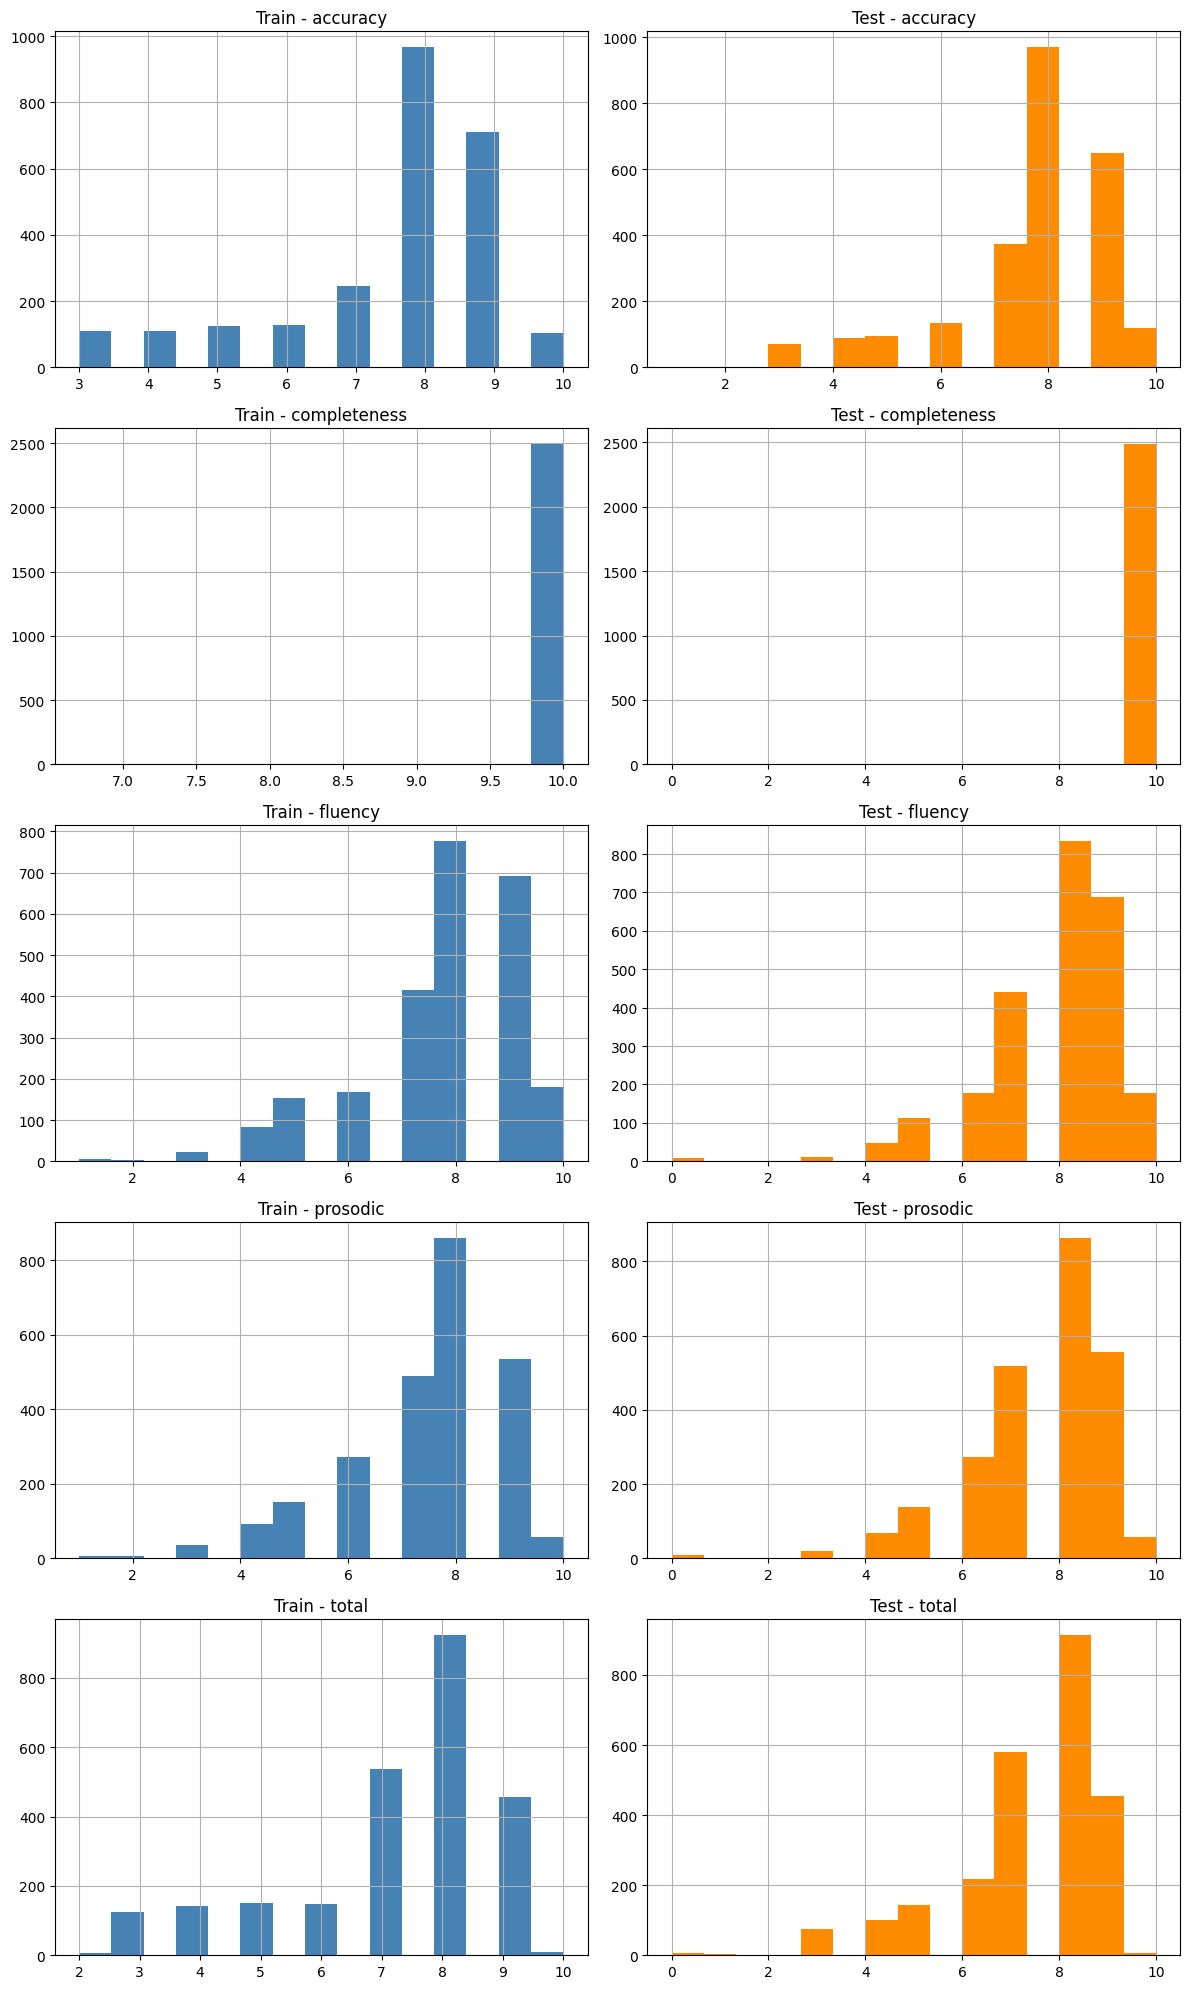

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = ["accuracy", "completeness", "fluency", "prosodic", "total"]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    train_df[col].hist(ax=axes[i][0], bins=15, color="steelblue")
    axes[i][0].set_title(f"Train - {col}")

    test_df[col].hist(ax=axes[i][1], bins=15, color="darkorange")
    axes[i][1].set_title(f"Test - {col}")

plt.tight_layout()
plt.show()

All four detail scores (accuracy, fluency, prosodic — and completeness with much less spread) are left-skewed, meaning most speakers score fairly well (7-9 out of 10) with a smaller tail of low scores.

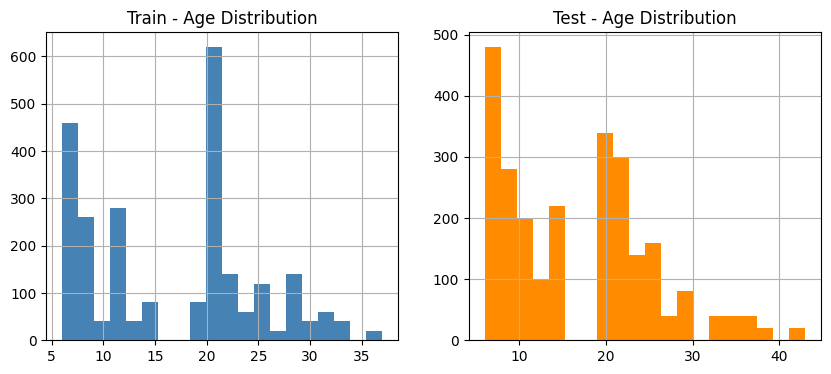

Train age range: 6 - 37
Test age range: 6 - 43


In [ ]:
# Age Column
fig, axes = plt.subplots(1, 2, figsize=(10,4))
train_df["age"].hist(ax=axes[0], bins=20, color="steelblue")
axes[0].set_title("Train - Age Distribution")

test_df["age"].hist(ax=axes[1], bins=20, color="darkorange")
axes[1].set_title("Test - Age Distribution")
plt.show()

print("Train age range:", train_df["age"].min(), "-", train_df["age"].max())
print("Test age range:", test_df["age"].min(), "-", test_df["age"].max())

The distribution is clearly bimodal, with one cluster around ages 6-15 (children) and another around ages 20-30 (adults).not a continuous age range. This is important context: pronunciation patterns and error types may differ significantly between these two groups, so results should ideally be interpreted per-group, not just in aggregate. Train and test show consistent age ranges (6-37 vs 6-43), though test includes a few older outliers.

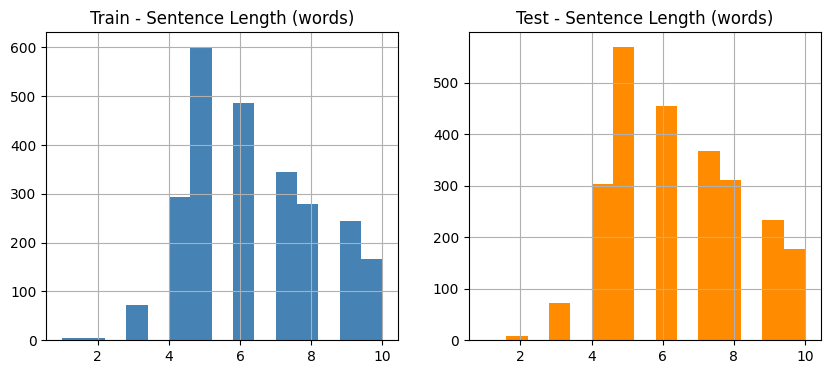

In [ ]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["text_length"] = test_df["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
train_df["text_length"].hist(ax=axes[0], bins=15, color="steelblue")
axes[0].set_title("Train - Sentence Length (words)")

test_df["text_length"].hist(ax=axes[1], bins=15, color="darkorange")
axes[1].set_title("Test - Sentence Length (words)")
plt.show()

Sentence lengths range mostly between 4-10 words, peaking around 5-6 words, with a very similar shape in both train and test splits. This consistency confirms the splits are comparable in terms of prompt complexity

In [ ]:
print(train_set[0]["words"])

[{'accuracy': 10, 'phones': ['W', 'IY0'], 'phones-accuracy': [2.0, 2.0], 'stress': 10, 'text': 'WE', 'total': 10, 'mispronunciations': []}, {'accuracy': 10, 'phones': ['K', 'AO0', 'L'], 'phones-accuracy': [2.0, 1.8, 1.8], 'stress': 10, 'text': 'CALL', 'total': 10, 'mispronunciations': []}, {'accuracy': 10, 'phones': ['IH0', 'T'], 'phones-accuracy': [2.0, 2.0], 'stress': 10, 'text': 'IT', 'total': 10, 'mispronunciations': []}, {'accuracy': 6, 'phones': ['B', 'EH0', 'R'], 'phones-accuracy': [2.0, 1.0, 1.0], 'stress': 10, 'text': 'BEAR', 'total': 6, 'mispronunciations': []}]


In [ ]:
# Word column
import pandas as pd

def flatten_words(df, split_name):
    rows = []

    for idx, row in df.iterrows():
        sentence_words = row["words"]

        for w in sentence_words:
            rows.append({
                "utt_index": idx,
                "speaker": row["speaker"],
                "gender": row["gender"],
                "age": row["age"],
                "sentence_text": row["text"],
                "word_text": w["text"],
                "word_accuracy": w["accuracy"],
                "word_total": w["total"],
                "stress": w["stress"],
                "mispronunciations": w["mispronunciations"],
            })

    result_df = pd.DataFrame(rows)
    result_df["split"] = split_name
    return result_df

train_words_df = flatten_words(train_df, "train")
test_words_df = flatten_words(test_df, "test")

print("Train words shape:", train_words_df.shape)
print("Test words shape:", test_words_df.shape)
train_words_df.head()

Train words shape: (15849, 11)
Test words shape: (15967, 11)


,utt_index,speaker,gender,age,sentence_text,word_text,word_accuracy,word_total,stress,mispronunciations,split
0,0,0001,m,6,WE CALL IT BEAR,WE,10,10,10,[],train
1,0,0001,m,6,WE CALL IT BEAR,CALL,10,10,10,[],train
2,0,0001,m,6,WE CALL IT BEAR,IT,10,10,10,[],train
3,0,0001,m,6,WE CALL IT BEAR,BEAR,6,6,10,[],train
4,1,0001,m,6,ZERO THREE FIVE ONE,ZERO,8,7,10,[],train


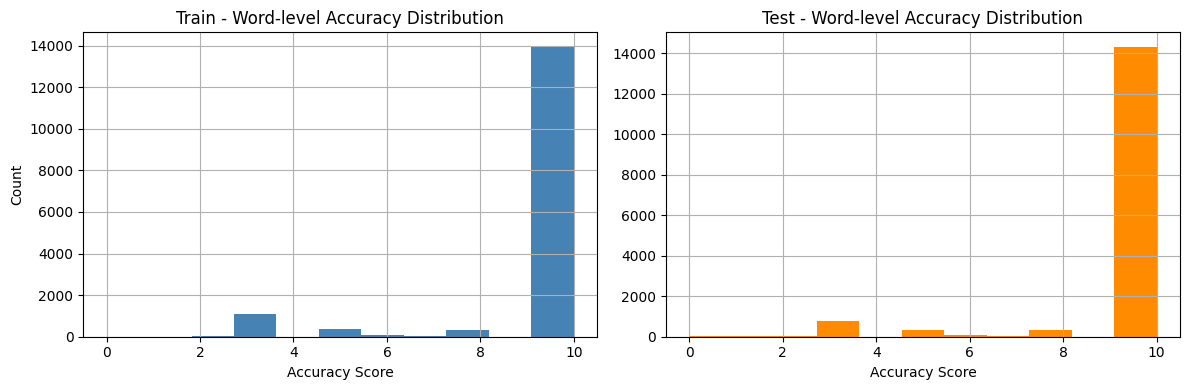

Train word_accuracy stats:
count    15849.000000
mean         9.319074
std          1.959996
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: word_accuracy, dtype: float64

Test word_accuracy stats:
count    15967.000000
mean         9.436525
std          1.790503
min          0.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: word_accuracy, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

train_words_df["word_accuracy"].hist(ax=axes[0], bins=11, color="steelblue")
axes[0].set_title("Train - Word-level Accuracy Distribution")
axes[0].set_xlabel("Accuracy Score")
axes[0].set_ylabel("Count")

test_words_df["word_accuracy"].hist(ax=axes[1], bins=11, color="darkorange")
axes[1].set_title("Test - Word-level Accuracy Distribution")
axes[1].set_xlabel("Accuracy Score")

plt.tight_layout()
plt.show()

print("Train word_accuracy stats:")
print(train_words_df["word_accuracy"].describe())
print("\nTest word_accuracy stats:")
print(test_words_df["word_accuracy"].describe())

In [ ]:
print("Train word_accuracy value counts:")
print(train_words_df["word_accuracy"].value_counts().sort_index())

print("\nTest word_accuracy value counts:")
print(test_words_df["word_accuracy"].value_counts().sort_index())

print(f"\n% of words with accuracy < 10 (train): {(train_words_df['word_accuracy'] < 10).mean()*100:.1f}%")
print(f"% of words with accuracy < 10 (test): {(test_words_df['word_accuracy'] < 10).mean()*100:.1f}%")
print(f"% of words with accuracy <= 5 (train): {(train_words_df['word_accuracy'] <= 5).mean()*100:.1f}%")

Train word_accuracy value counts:
word_accuracy
0         3
1         6
2        40
3      1094
5       349
6        62
7        30
8       322
9         3
10    13940
Name: count, dtype: int64

Test word_accuracy value counts:
word_accuracy
0        27
1        18
2        26
3       787
4         6
5       356
6        77
7        26
8       321
9         4
10    14319
Name: count, dtype: int64

% of words with accuracy < 10 (train): 12.0%
% of words with accuracy < 10 (test): 10.3%
% of words with accuracy <= 5 (train): 9.4%


**Note on word-level accuracy distribution — Final summary:**
- ~88-90% of words have perfect accuracy (10)
- ~9-10% of words show clear pronunciation issues (accuracy ≤ 5)
- Only ~2-3% fall in the "borderline" range (6-9)

This near-binary pattern (mostly perfect vs. clearly problematic, with very
few borderline cases) is actually useful for our threshold calibration:
it suggests the confidence-based threshold doesn't need to be finely tuned
to capture subtle gradations — it mainly needs to reliably separate the
small but important minority of clearly mispronounced words (~10%) from
the majority of correct ones. We will treat this ~10% as our target
"positive class" when evaluating how well WhisperX confidence scores
identify real pronunciation problems.

In [ ]:
meta = train_set[0]["audio"].metadata
print(dir(meta))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__replace__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'begin_stream_seconds_from_header', 'bit_rate', 'codec', 'duration_seconds_from_header', 'num_channels', 'path', 'sample_format', 'sample_rate', 'stream_index']


In [ ]:
sample = train_set[0]["audio"]
print(sample.metadata)

AudioStreamMetadata:
  duration_seconds_from_header: 2.58
  begin_stream_seconds_from_header: None
  bit_rate: 256000.0
  codec: pcm_s16le
  stream_index: 0
  sample_rate: 16000
  num_channels: 1
  sample_format: s16



In [ ]:
sample_rates = set()
channels = set()
durations = []

for i in range(len(train_set)):
    meta = train_set[i]["audio"].metadata
    sample_rates.add(meta.sample_rate)
    channels.add(meta.num_channels)
    durations.append(meta.duration_seconds_from_header)

print("Unique sample rates found:", sample_rates)
print("Unique channel counts found:", channels)

import pandas as pd
durations_series = pd.Series(durations)
print("\nDuration stats (seconds) - FULL dataset:")
print(durations_series.describe())

Unique sample rates found: {16000}
Unique channel counts found: {1}

Duration stats (seconds) - FULL dataset:
count    2500.000000
mean        4.141644
std         2.023709
min         1.590000
25%         2.997000
50%         3.549500
75%         4.529250
max        20.408000
dtype: float64


**Note on audio duration (full dataset):**
Across all 2,500 files, duration ranges from 1.6s to 20.4s (mean ~4.1s,
median ~3.5s).
All files remain consistently 16kHz mono — no resampling needed. The
20.4s outlier(s) are worth keeping in mind for processing time/memory
when running WhisperX on the full set, though not concerning at this scale.

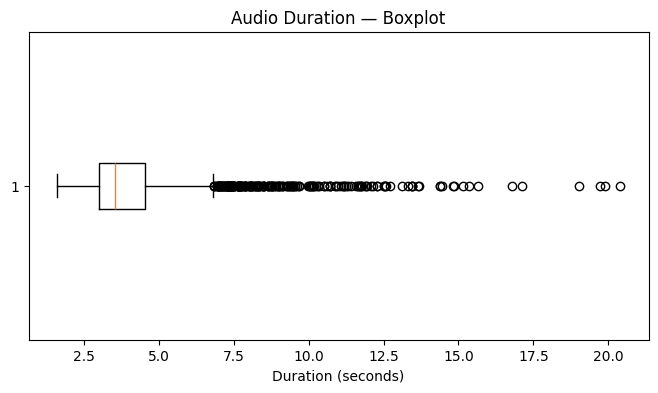

In [ ]:
plt.figure(figsize=(8,4))
plt.boxplot(durations_series, vert=False)
plt.title("Audio Duration — Boxplot")
plt.xlabel("Duration (seconds)")
plt.show()

In [ ]:
# Outliers for audio duration
Q1 = durations_series.quantile(0.25)
Q3 = durations_series.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = durations_series[(durations_series < lower_bound) | (durations_series > upper_bound)]

print(f"Lower bound: {lower_bound:.2f}s, Upper bound: {upper_bound:.2f}s")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values:\n{outliers.sort_values(ascending=False)}")

Lower bound: 0.70s, Upper bound: 6.83s
Number of outliers: 211
Outlier values:
1925    20.408
1924    19.903
1934    19.735
1935    19.011
1962    17.106
         ...  
2449     6.938
2227     6.923
1966     6.853
1976     6.836
2163     6.834
Length: 211, dtype: float64


## **Bivariate Correlations**

<Figure size 1000x500 with 0 Axes>

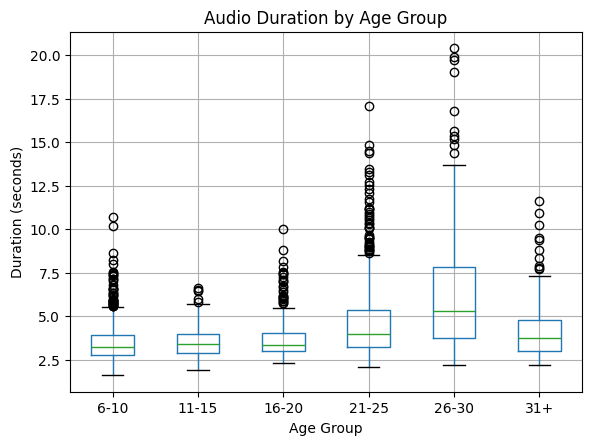

In [ ]:
train_df["duration"] = durations
train_df["age_group"] = pd.cut(train_df["age"], bins=[0, 10, 15, 20, 25, 30, 100],
                                 labels=["6-10", "11-15", "16-20", "21-25", "26-30", "31+"])

plt.figure(figsize=(10,5))
train_df.boxplot(column="duration", by="age_group")
plt.title("Audio Duration by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Duration (seconds)")
plt.show()

**Note on Age vs Duration (Bivariate Analysis):**
Contrary to initial expectations, younger speakers (ages 6-20) have shorter
and more consistent recording durations (median 3.3-3.5s), while the 26-30
age group shows both the longest median duration (~5.3s) and the widest
spread, including nearly all extreme outliers (15-20+ seconds). This
suggests audio duration is not simply explained by age alone — the 26-30
group may include speakers with more hesitation or lower fluency, which
would need further investigation

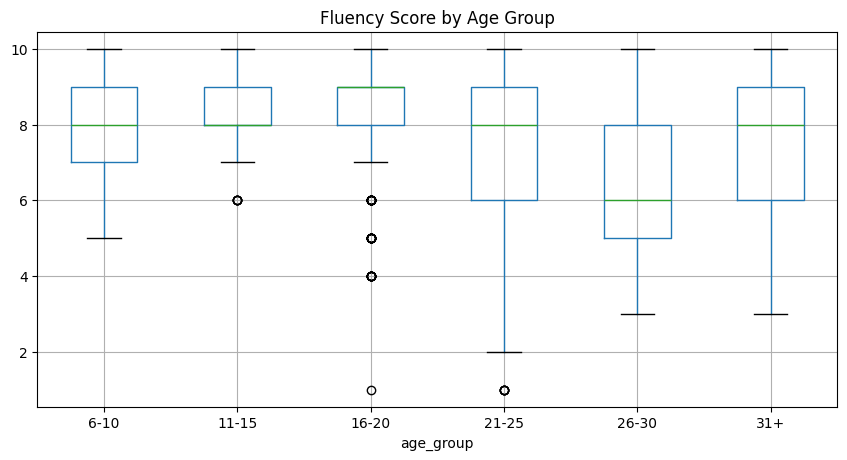

In [ ]:
train_df.boxplot(column="fluency", by="age_group", figsize=(10,5))
plt.title("Fluency Score by Age Group")
plt.suptitle("")
plt.show()

**Note on Age vs Fluency (Bivariate Analysis — Confirms Duration Finding):**
The 26-30 age group, which showed the longest and most variable audio
durations, also shows the lowest fluency scores (median = 6, vs ~8 for
other groups) — with the entire interquartile range shifted lower than
any other age bracket. This confirms our hypothesis: longer recordings
in this group are driven by lower speaking fluency (hesitation, pauses,
repetition) rather than sentence complexity or recording artifacts.

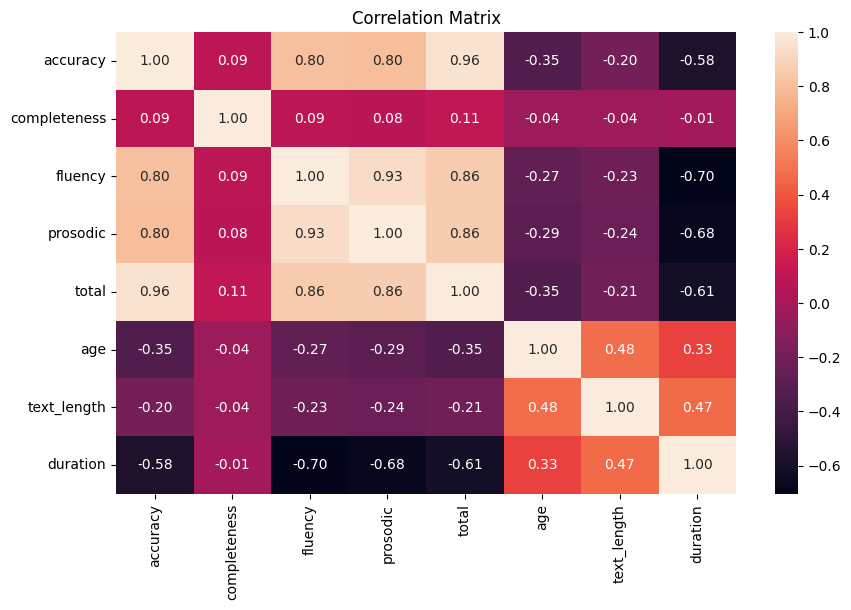

In [47]:
import seaborn as sns
numeric_df = train_df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

**Note on Correlation Matrix (Bivariate Summary):**
The strongest cross-feature relationship is between `duration` and
`fluency` (r=-0.70), followed by `prosodic` (r=-0.68) and `total`
(r=-0.61) — confirming that longer recordings are strongly associated
with lower speech quality scores, most likely due to hesitation and
pauses. Notably, `duration` correlates less strongly with `accuracy`
alone (r=-0.58), suggesting sentence-level accuracy (correct sound
production) is somewhat more independent of speaking pace/fluency than
the other scores.

Importantly, `age` itself shows only weak-to-moderate correlations with
all scores (r between -0.27 and -0.35) — weaker than `duration`'s
correlations. This suggests the earlier age-group pattern (26-30 having
lower fluency) is likely mediated through duration/hesitation rather
than age being a direct driver of pronunciation quality.

## EDA Key Findings Summary

### Dataset Structure & Quality
- 2,500 utterances / 125 speakers per split (train/test), officially balanced, **zero speaker overlap** — no data leakage risk.
- No missing values across any column.

### Speaker Demographics
- Age is **bimodal**: children (6-15) and adults (~20-30) as two distinct groups.
- Gender is roughly balanced (54%/46%), reversed between train/test — not a concern.

### Word-Level Accuracy (Core Finding for Threshold Design)
- After flattening: 15,900 words per split (~6.3 words/sentence).
- **Severe imbalance:** 88-90% of words are perfect (accuracy=10), only ~9-10% show real issues (≤5), 2-3% borderline.
- → Standard accuracy is a misleading evaluation metric; **Precision/Recall** must be used, treating accuracy≤5 words as the "positive class" (the errors we need to detect).

### Audio Format Check
- **100% consistent**: 16kHz sample rate, mono channel across all 2,500 files — perfectly matches WhisperX's expected input, **no preprocessing needed**.
- Duration ranges 1.6s–20.4s (mean 4.1s), with 211 statistical outliers (8.4%) — a wide but natural spread, not a data quality issue.

### Bivariate Analysis (Key Insight)
- **Duration strongly correlates with speech quality** — especially fluency (r=-0.70), prosodic (r=-0.68), total (r=-0.61). Longer recordings = more hesitation = lower scores.
- Duration correlates more weakly with accuracy specifically (r=-0.58) — pronunciation accuracy is somewhat independent of speaking pace.
- **Age itself is only weakly correlated** with scores (r≈-0.3) — the earlier "26-30 age group has lower fluency" pattern is likely *explained by* duration/hesitation, not age directly.

### What This Means for the Next Step (WhisperX Evaluation)
1. Use Precision/Recall (not raw accuracy) when calibrating the confidence threshold.
2. Watch for duration as a possible confound — long/hesitant recordings may affect WhisperX confidence differently than short, clean ones.
3. Dataset is clean and ready — no resampling, no missing data, no leakage — safe to proceed directly to running WhisperX.

## Running WhisperX on speechocean762

Now that the EDA is complete and the data is confirmed clean (16kHz mono audio,
no missing values, no speaker leakage), this section moves to the modeling stage.

**Goal:** Run WhisperX (a frozen, pretrained model — no fine-tuning) on a sample
of speechocean762 audio, extract a transcript and per-word confidence score for
each recording, then compare that confidence against the dataset's human-annotated
word-level accuracy scores. The outcome of this comparison will be used to
calibrate a confidence threshold that flags words as "ok" vs "needs attention" —
evaluated using Precision/Recall, given the class imbalance found earlier.

In [ ]:
!pip install -q whisperx

In [ ]:
import whisperx
print("WhisperX imported successfully!")

WhisperX imported successfully!


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load WhisperX alignment model
align_model, align_metadata = whisperx.load_align_model(
    language_code="en",
    device=device
)

print("Alignment model loaded successfully!")

Using device: cpu
Alignment model loaded successfully!


In [ ]:
def align_reference_text(sample):

    # Get audio
    audio_samples = sample["audio"].get_all_samples()

    audio = audio_samples.data.numpy().squeeze()
    sample_rate = audio_samples.sample_rate

    # Audio duration
    duration = len(audio) / sample_rate

    # Correct sentence from the dataset
    reference_segments = [
        {
            "start": 0.0,
            "end": duration,
            "text": sample["text"]
        }
    ]

    # Align the correct text with the audio
    aligned_result = whisperx.align(
        reference_segments,
        align_model,
        align_metadata,
        audio,
        device,
        return_char_alignments=False
    )

    return aligned_result["word_segments"]

In [ ]:
sample = train_set[0]

aligned_words = align_reference_text(sample)

print("Target sentence:")
print(sample["text"])

print("\nWhisperX aligned words:")
print(aligned_words)

Target sentence:
WE CALL IT BEAR

WhisperX aligned words:
[{'word': 'WE', 'start': 0.665, 'end': 0.947, 'score': np.float64(0.916)}, {'word': 'CALL', 'start': 1.048, 'end': 1.31, 'score': np.float64(0.866)}, {'word': 'IT', 'start': 1.391, 'end': 1.471, 'score': np.float64(0.983)}, {'word': 'BEAR', 'start': 1.653, 'end': 1.895, 'score': np.float64(0.672)}]


In [ ]:
print("Ground Truth from dataset:\n")

for word in sample["words"]:
    print(word)

Ground Truth from dataset:

{'accuracy': 10, 'phones': ['W', 'IY0'], 'phones-accuracy': [2.0, 2.0], 'stress': 10, 'text': 'WE', 'total': 10, 'mispronunciations': []}
{'accuracy': 10, 'phones': ['K', 'AO0', 'L'], 'phones-accuracy': [2.0, 1.8, 1.8], 'stress': 10, 'text': 'CALL', 'total': 10, 'mispronunciations': []}
{'accuracy': 10, 'phones': ['IH0', 'T'], 'phones-accuracy': [2.0, 2.0], 'stress': 10, 'text': 'IT', 'total': 10, 'mispronunciations': []}
{'accuracy': 6, 'phones': ['B', 'EH0', 'R'], 'phones-accuracy': [2.0, 1.0, 1.0], 'stress': 10, 'text': 'BEAR', 'total': 6, 'mispronunciations': []}


In [ ]:
import pandas as pd

comparison_rows = []

for gold_word, aligned_word in zip(sample["words"], aligned_words):
    comparison_rows.append({
        "word": gold_word["text"],
        "human_accuracy": gold_word["accuracy"],
        "whisperx_score": float(aligned_word["score"])
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,word,human_accuracy,whisperx_score
0,WE,10,0.916
1,CALL,10,0.866
2,IT,10,0.983
3,BEAR,6,0.672


In [ ]:
import pandas as pd
import re

def normalize_word(word):
    return re.sub(r"[^a-z']", "", word.lower())


N_SAMPLES = 100

all_rows = []
skipped_sentences = 0
error_sentences = 0

for i in range(N_SAMPLES):

    sample = train_set[i]

    try:
        # Run WhisperX forced alignment
        aligned_words = align_reference_text(sample)

        # Ground truth words from SpeechOcean762
        gold_words = sample["words"]

        # Normalize words before comparing
        gold_text = [
            normalize_word(word["text"])
            for word in gold_words
        ]

        aligned_text = [
            normalize_word(word["word"])
            for word in aligned_words
        ]

        # IMPORTANT:
        # Only use the sentence if words match exactly
        if gold_text != aligned_text:
            skipped_sentences += 1
            continue

        # Now it is safe to match word-by-word
        for gold_word, aligned_word in zip(gold_words, aligned_words):

            score = aligned_word.get("score")

            # Skip a word if WhisperX did not return a score
            if score is None:
                continue

            all_rows.append({
                "sample_id": i,
                "word": gold_word["text"],
                "human_accuracy": gold_word["accuracy"],
                "whisperx_score": float(score)
            })

    except Exception as e:
        error_sentences += 1
        print(f"Error in sample {i}: {e}")

    # Just to see progress
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{N_SAMPLES}")


comparison_df = pd.DataFrame(all_rows)

print("\nFinished!")
print("Sentences tested:", N_SAMPLES)
print("Sentences skipped because words did not match:", skipped_sentences)
print("Sentences with errors:", error_sentences)
print("Total usable words:", len(comparison_df))

comparison_df.head(20)

Processed 10/100
Processed 20/100
Processed 30/100
Processed 40/100
Processed 50/100
Processed 60/100
Processed 70/100
Processed 80/100
Processed 90/100
Processed 100/100

Finished!
Sentences tested: 100
Sentences skipped because words did not match: 0
Sentences with errors: 0
Total usable words: 485


,sample_id,word,human_accuracy,whisperx_score
0,0,WE,10,0.916
1,0,CALL,10,0.866
2,0,IT,10,0.983
3,0,BEAR,6,0.672
4,1,ZERO,8,0.825
5,1,THREE,8,0.661
6,1,FIVE,10,0.808
7,1,ONE,10,0.693
8,2,THREE,10,0.838
9,2,TWO,10,0.773


In [ ]:
# Create the ground-truth label

comparison_df["pronunciation_issue"] = (
    comparison_df["human_accuracy"] <= 6
).astype(int)

print("Class counts:")
print(comparison_df["pronunciation_issue"].value_counts())

print("\nClass percentages:")
print(
    comparison_df["pronunciation_issue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nAverage WhisperX score by class:")
print(
    comparison_df
    .groupby("pronunciation_issue")["whisperx_score"]
    .describe()
)

Class counts:
pronunciation_issue
0    473
1     12
Name: count, dtype: int64

Class percentages:
pronunciation_issue
0    97.53
1     2.47
Name: proportion, dtype: float64

Average WhisperX score by class:
                     count      mean       std    min      25%    50%    75%  \
pronunciation_issue                                                            
0                    473.0  0.813307  0.155480  0.000  0.75100  0.851  0.910   
1                     12.0  0.647917  0.233386  0.005  0.58075  0.741  0.784   

                       max  
pronunciation_issue         
0                    1.000  
1                    0.844  


In [35]:
from tqdm.auto import tqdm
import pandas as pd

all_train_rows = []
skipped_sentences = 0
error_sentences = 0

for i in tqdm(range(len(train_set)), desc="Processing train set"):

    sample = train_set[i]

    try:
        # 1. Forced alignment using the correct target sentence
        aligned_words = align_reference_text(sample)

        # 2. Ground-truth words
        gold_words = sample["words"]

        # 3. Normalize both sides
        gold_text = [
            normalize_word(word["text"])
            for word in gold_words
        ]

        aligned_text = [
            normalize_word(word["word"])
            for word in aligned_words
        ]

        # 4. Safety check:
        # Never compare word-by-word unless the words match exactly
        if gold_text != aligned_text:
            skipped_sentences += 1
            continue

        # 5. Combine human labels with WhisperX scores
        for gold_word, aligned_word in zip(gold_words, aligned_words):

            score = aligned_word.get("score")

            if score is None:
                continue

            human_accuracy = gold_word["accuracy"]

            all_train_rows.append({
                "sample_id": i,
                "word": gold_word["text"],
                "human_accuracy": human_accuracy,
                "whisperx_score": float(score),

                # Ground truth:
                # 1 = pronunciation issue
                # 0 = acceptable
                "pronunciation_issue": int(human_accuracy <= 6)
            })

    except Exception as e:
        error_sentences += 1
        print(f"\nError in sample {i}: {e}")


train_alignment_df = pd.DataFrame(all_train_rows)

print("\n===== FINAL TRAIN ALIGNMENT SUMMARY =====")
print("Total train sentences:", len(train_set))
print("Skipped sentences:", skipped_sentences)
print("Sentences with errors:", error_sentences)
print("Total usable words:", len(train_alignment_df))

print("\nClass counts:")
print(train_alignment_df["pronunciation_issue"].value_counts())

print("\nClass percentages:")
print(
    train_alignment_df["pronunciation_issue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nWhisperX scores by class:")
print(
    train_alignment_df
    .groupby("pronunciation_issue")["whisperx_score"]
    .describe()
)

Processing train set:   0%|          | 0/2500 [00:00<?, ?it/s]


===== FINAL TRAIN ALIGNMENT SUMMARY =====
Total train sentences: 2500
Skipped sentences: 1
Sentences with errors: 0
Total usable words: 15841

Class counts:
pronunciation_issue
0    14290
1     1551
Name: count, dtype: int64

Class percentages:
pronunciation_issue
0    90.21
1     9.79
Name: proportion, dtype: float64

WhisperX scores by class:
                       count      mean       std  min    25%    50%    75%  \
pronunciation_issue                                                          
0                    14290.0  0.792901  0.185528  0.0  0.734  0.841  0.911   
1                     1551.0  0.657127  0.195967  0.0  0.561  0.694  0.801   

                       max  
pronunciation_issue         
0                    1.000  
1                    0.996  


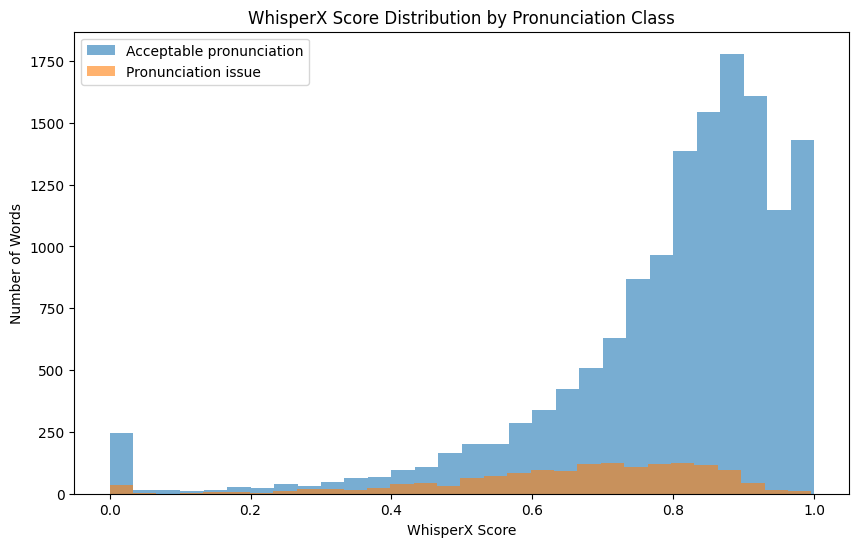

In [36]:
import matplotlib.pyplot as plt

acceptable_scores = train_alignment_df[
    train_alignment_df["pronunciation_issue"] == 0
]["whisperx_score"]

issue_scores = train_alignment_df[
    train_alignment_df["pronunciation_issue"] == 1
]["whisperx_score"]

plt.figure(figsize=(10, 6))

plt.hist(
    acceptable_scores,
    bins=30,
    alpha=0.6,
    label="Acceptable pronunciation"
)

plt.hist(
    issue_scores,
    bins=30,
    alpha=0.6,
    label="Pronunciation issue"
)

plt.xlabel("WhisperX Score")
plt.ylabel("Number of Words")
plt.title("WhisperX Score Distribution by Pronunciation Class")
plt.legend()

plt.show()

In [37]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_score, recall_score, f1_score

y_true = train_alignment_df["pronunciation_issue"]

threshold_results = []

# Try thresholds from 0.00 to 1.00
thresholds = np.arange(0.00, 1.01, 0.01)

for threshold in thresholds:

    # Low WhisperX score = predicted pronunciation issue
    y_pred = (
        train_alignment_df["whisperx_score"] < threshold
    ).astype(int)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })


threshold_df = pd.DataFrame(threshold_results)

threshold_df.head()


,threshold,precision,recall,f1
0,0.00,0.000000,0.000000,0.000000
1,0.01,0.128099,0.019987,0.034579
2,0.02,0.125000,0.021277,0.036364
3,0.03,0.122744,0.021921,0.037199
4,0.04,0.132404,0.024500,0.041349


In [40]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold based on F1:")
print(best_row)

Best threshold based on F1:
threshold    0.730000
precision    0.206465
recall       0.584784
f1           0.305182
Name: 73, dtype: float64


In [41]:
threshold_df.sort_values(
    by="f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
73,0.73,0.206465,0.584784,0.305182
74,0.74,0.203632,0.607350,0.305002
75,0.75,0.199511,0.631850,0.303265
72,0.72,0.208143,0.557060,0.303052
71,0.71,0.210606,0.535139,0.302258
70,0.70,0.213027,0.514507,0.301303
69,0.69,0.215311,0.493230,0.299765
76,0.76,0.193303,0.655061,0.298516
68,0.68,0.216896,0.466796,0.296175
77,0.77,0.188951,0.676983,0.295442


In [42]:
best_threshold = best_row["threshold"]

print("Chosen candidate threshold:", best_threshold)

Chosen candidate threshold: 0.73


In [43]:
from tqdm.auto import tqdm
import pandas as pd

all_test_rows = []
skipped_test_sentences = 0
error_test_sentences = 0

for i in tqdm(range(len(test_set)), desc="Processing test set"):

    sample = test_set[i]

    try:
        aligned_words = align_reference_text(sample)

        gold_words = sample["words"]

        gold_text = [
            normalize_word(word["text"])
            for word in gold_words
        ]

        aligned_text = [
            normalize_word(word["word"])
            for word in aligned_words
        ]

        # Only use sentences where alignment matches exactly
        if gold_text != aligned_text:
            skipped_test_sentences += 1
            continue

        for gold_word, aligned_word in zip(gold_words, aligned_words):

            score = aligned_word.get("score")

            if score is None:
                continue

            human_accuracy = gold_word["accuracy"]

            all_test_rows.append({
                "sample_id": i,
                "word": gold_word["text"],
                "human_accuracy": human_accuracy,
                "whisperx_score": float(score),
                "pronunciation_issue": int(human_accuracy <= 6)
            })

    except Exception as e:
        error_test_sentences += 1
        print(f"\nError in test sample {i}: {e}")


test_alignment_df = pd.DataFrame(all_test_rows)

print("\n===== TEST ALIGNMENT SUMMARY =====")
print("Total test sentences:", len(test_set))
print("Skipped sentences:", skipped_test_sentences)
print("Sentences with errors:", error_test_sentences)
print("Total usable words:", len(test_alignment_df))

print("\nClass counts:")
print(test_alignment_df["pronunciation_issue"].value_counts())

print("\nClass percentages:")
print(
    test_alignment_df["pronunciation_issue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Processing test set:   0%|          | 0/2500 [00:00<?, ?it/s]


===== TEST ALIGNMENT SUMMARY =====
Total test sentences: 2500
Skipped sentences: 2
Sentences with errors: 0
Total usable words: 15951

Class counts:
pronunciation_issue
0    14662
1     1289
Name: count, dtype: int64

Class percentages:
pronunciation_issue
0    91.92
1     8.08
Name: proportion, dtype: float64


In [44]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Threshold chosen ONLY from the training set
FINAL_THRESHOLD = 0.73

# Ground truth
y_test_true = test_alignment_df["pronunciation_issue"]

# WhisperX prediction
# score < 0.73 --> pronunciation issue
# score >= 0.73 --> acceptable
y_test_pred = (
    test_alignment_df["whisperx_score"] < FINAL_THRESHOLD
).astype(int)

# Metrics
test_precision = precision_score(
    y_test_true,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_true,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_true,
    y_test_pred,
    zero_division=0
)

print("===== TEST RESULTS =====")
print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_true,
    y_test_pred
).ravel()

print("\n===== CONFUSION MATRIX =====")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

===== TEST RESULTS =====
Threshold: 0.73
Precision: 0.1638
Recall:    0.5694
F1 Score:  0.2544

===== CONFUSION MATRIX =====
True Negatives : 10914
False Positives: 3748
False Negatives: 555
True Positives : 734


In [45]:
# Add predictions to the test dataframe
test_alignment_df["predicted_issue"] = y_test_pred

# False Positives:
# WhisperX says issue, but human label says acceptable
false_positives = test_alignment_df[
    (test_alignment_df["pronunciation_issue"] == 0) &
    (test_alignment_df["predicted_issue"] == 1)
]

false_positives.head(20)

,sample_id,word,human_accuracy,whisperx_score,pronunciation_issue,predicted_issue
1,0,IS,10,0.560,0,1
3,0,TO,10,0.649,0,1
4,0,SEE,10,0.537,0,1
11,2,FOUR,10,0.699,0,1
14,3,THREE,8,0.593,0,1
16,3,TWO,10,0.000,0,1
26,6,FIVE,8,0.565,0,1
27,6,NINE,10,0.615,0,1
33,8,IS,10,0.712,0,1
35,8,AT,10,0.324,0,1


In [46]:
# False Negatives:
# Human says there is an issue,
# but WhisperX did not detect it
false_negatives = test_alignment_df[
    (test_alignment_df["pronunciation_issue"] == 1) &
    (test_alignment_df["predicted_issue"] == 0)
]

false_negatives.head(20)

,sample_id,word,human_accuracy,whisperx_score,pronunciation_issue,predicted_issue
185,33,INDUSTRY,6,0.875,1,0
221,38,PROOF,3,0.841,1,0
262,47,GROUND,5,0.873,1,0
279,52,LISA,5,0.802,1,0
296,55,BANGKOK,5,0.855,1,0
301,56,CAIRO,3,0.796,1,0
307,57,IT,3,0.898,1,0
357,70,JEANS,5,0.770,1,0
499,102,KING,3,0.876,1,0
567,117,BOOT,3,0.860,1,0


## WhisperX Pronunciation Evaluation

After loading WhisperX, we used the English alignment model to perform forced alignment between the student's audio and the correct reference sentence from the dataset.

For each word, WhisperX returned:
- Start time
- End time
- Alignment score

The WhisperX word scores were then compared with the human pronunciation accuracy scores provided by SpeechOcean762.

A binary label was created:
- Human accuracy >= 7 → Acceptable pronunciation
- Human accuracy <= 6 → Pronunciation issue

### Training Set

WhisperX alignment was successfully applied to the training set.

- Total sentences: 2500
- Usable words: 15,841
- Pronunciation issues: 1,551
- Acceptable words: 14,290

Different thresholds were tested using Precision, Recall, and F1-score.

The best threshold on the training set was:

**Threshold = 0.73**

Training results:
- Precision: 0.2065
- Recall: 0.5848
- F1-score: 0.3052

### Test Set

The same threshold was then evaluated on the test set without changing it.

- Total sentences: 2500
- Usable words: 15,951

Test results:
- Precision: 0.1638
- Recall: 0.5694
- F1-score: 0.2544

The error analysis showed that some correctly pronounced words received very low WhisperX scores, while some incorrectly pronounced words received high scores.

### Conclusion

WhisperX word-level alignment scores contain some useful pronunciation information, but a single threshold is not reliable enough for pronunciation error detection.

This approach will be kept as a baseline, and the next step is to investigate phone-level information and additional pronunciation features.